In [1]:
import tensorflow as tf
import keras
import pandas
import sklearn
import matplotlib

In [2]:
import pandas as pd

In [4]:
import os
print(os.getcwd())


C:\Users\hieii


In [6]:
df = pd.read_csv('housepricedata.csv')


In [7]:
df = pd.read_csv('housepricedata.csv')

In [8]:
df

,LotArea,OverallQual,OverallCond,TotalBsmtSF,FullBath,HalfBath,BedroomAbvGr,TotRmsAbvGrd,Fireplaces,GarageArea,AboveMedianPrice
0,8450,7,5,856,2,1,3,8,0,548,1
1,9600,6,8,1262,2,0,3,6,1,460,1
2,11250,7,5,920,2,1,3,6,1,608,1
3,9550,7,5,756,1,0,3,7,1,642,0
4,14260,8,5,1145,2,1,4,9,1,836,1
...,...,...,...,...,...,...,...,...,...,...,...
1455,7917,6,5,953,2,1,3,7,1,460,1
1456,13175,6,6,1542,2,0,3,7,2,500,1
1457,9042,7,9,1152,2,0,4,9,2,252,1
1458,9717,5,6,1078,1,0,2,5,0,240,0


In [9]:
dataset = df.values


In [10]:
dataset

array([[ 8450,     7,     5, ...,     0,   548,     1],
       [ 9600,     6,     8, ...,     1,   460,     1],
       [11250,     7,     5, ...,     1,   608,     1],
       ...,
       [ 9042,     7,     9, ...,     2,   252,     1],
       [ 9717,     5,     6, ...,     0,   240,     0],
       [ 9937,     5,     6, ...,     0,   276,     0]], dtype=int64)

In [11]:
X = dataset[:,0:10]

In [12]:
Y = dataset[:,10]


In [13]:
from sklearn import preprocessing

In [14]:
min_max_scaler = preprocessing.MinMaxScaler()
X_scale = min_max_scaler.fit_transform(X)


In [15]:
X_scale


array([[0.0334198 , 0.66666667, 0.5       , ..., 0.5       , 0.        ,
        0.3864598 ],
       [0.03879502, 0.55555556, 0.875     , ..., 0.33333333, 0.33333333,
        0.32440056],
       [0.04650728, 0.66666667, 0.5       , ..., 0.33333333, 0.33333333,
        0.42877292],
       ...,
       [0.03618687, 0.66666667, 1.        , ..., 0.58333333, 0.66666667,
        0.17771509],
       [0.03934189, 0.44444444, 0.625     , ..., 0.25      , 0.        ,
        0.16925247],
       [0.04037019, 0.44444444, 0.625     , ..., 0.33333333, 0.        ,
        0.19464034]])

In [16]:
from sklearn.model_selection import train_test_split

In [17]:
X_train, X_val_and_test, Y_train, Y_val_and_test = train_test_split(X_scale, Y, test_size=0.3)


In [18]:
X_val, X_test, Y_val, Y_test = train_test_split(X_val_and_test, Y_val_and_test, test_size=0.5)


In [19]:
print(X_train.shape, X_val.shape, X_test.shape, Y_train.shape, Y_val.shape, Y_test.shape)


(1022, 10) (219, 10) (219, 10) (1022,) (219,) (219,)


In [20]:
from keras.models import Sequential
from keras.layers import Dense

In [21]:
model = Sequential([
    Dense(32, activation='relu', input_shape=(10,)),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid'),
])

In [22]:
model.compile(optimizer='sgd',
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [23]:
hist = model.fit(X_train, Y_train,
          batch_size=32, epochs=100,
          validation_data=(X_val, Y_val))


Epoch 1/100
32/32 [==============================] - 3s 12ms/step - loss: 0.6972 - accuracy: 0.4922 - val_loss: 0.6873 - val_accuracy: 0.5388
Epoch 2/100
32/32 [==============================] - 0s 2ms/step - loss: 0.6902 - accuracy: 0.4990 - val_loss: 0.6839 - val_accuracy: 0.5845
Epoch 3/100
32/32 [==============================] - 0s 2ms/step - loss: 0.6845 - accuracy: 0.6076 - val_loss: 0.6809 - val_accuracy: 0.7260
Epoch 4/100
32/32 [==============================] - 0s 2ms/step - loss: 0.6794 - accuracy: 0.7280 - val_loss: 0.6779 - val_accuracy: 0.6986
Epoch 5/100
32/32 [==============================] - 0s 3ms/step - loss: 0.6746 - accuracy: 0.7104 - val_loss: 0.6748 - val_accuracy: 0.6758
Epoch 6/100
32/32 [==============================] - 0s 4ms/step - loss: 0.6699 - accuracy: 0.7045 - val_loss: 0.6716 - val_accuracy: 0.6575
Epoch 7/100
32/32 [==============================] - 0s 4ms/step - loss: 0.6653 - accuracy: 0.6810 - val_loss: 0.6682 - val_accuracy: 0.6393
Epoch 8/100


Epoch 59/100
32/32 [==============================] - 0s 4ms/step - loss: 0.3450 - accuracy: 0.8689 - val_loss: 0.3473 - val_accuracy: 0.8721
Epoch 60/100
32/32 [==============================] - 0s 4ms/step - loss: 0.3422 - accuracy: 0.8699 - val_loss: 0.3439 - val_accuracy: 0.8721
Epoch 61/100
32/32 [==============================] - 0s 3ms/step - loss: 0.3397 - accuracy: 0.8728 - val_loss: 0.3414 - val_accuracy: 0.8721
Epoch 62/100
32/32 [==============================] - 0s 4ms/step - loss: 0.3374 - accuracy: 0.8689 - val_loss: 0.3378 - val_accuracy: 0.8767
Epoch 63/100
32/32 [==============================] - 0s 4ms/step - loss: 0.3354 - accuracy: 0.8728 - val_loss: 0.3355 - val_accuracy: 0.8767
Epoch 64/100
32/32 [==============================] - 0s 4ms/step - loss: 0.3332 - accuracy: 0.8708 - val_loss: 0.3338 - val_accuracy: 0.8721
Epoch 65/100
32/32 [==============================] - 0s 4ms/step - loss: 0.3314 - accuracy: 0.8728 - val_loss: 0.3306 - val_accuracy: 0.8767
Epoch 

In [24]:
model.evaluate(X_test, Y_test)[1]

7/7 [==============================] - 0s 2ms/step - loss: 0.2634 - accuracy: 0.8767


0.8767123222351074

In [25]:
import matplotlib.pyplot as plt


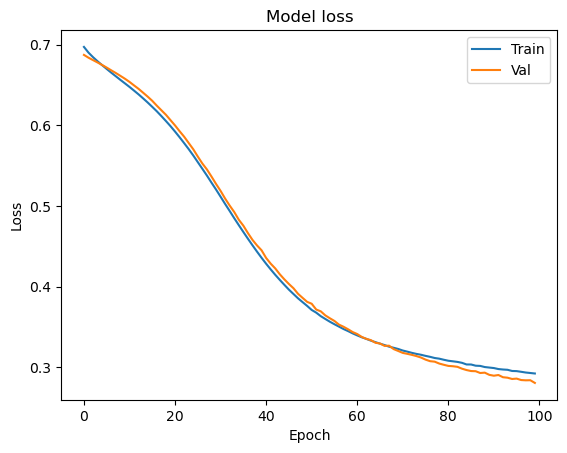

In [26]:
plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper right')
plt.show()

In [27]:
plt.plot(hist.history['acc'])
plt.plot(hist.history['val_acc'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='lower right')
plt.show()

KeyError: 'acc'

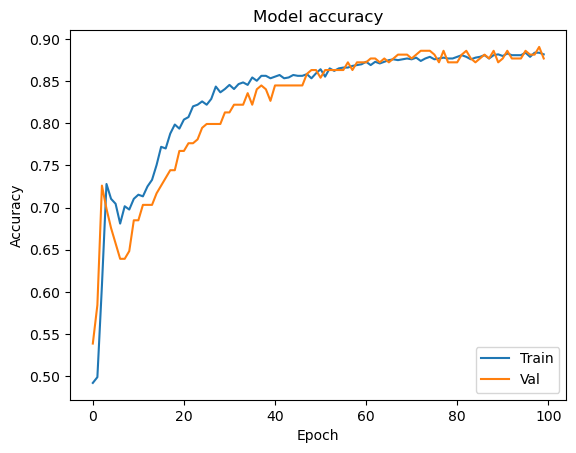

In [29]:
plt.plot(hist.history['accuracy'])
plt.plot(hist.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='lower right')
plt.show()


In [30]:
model_2 = Sequential([
    Dense(1000, activation='relu', input_shape=(10,)),
    Dense(1000, activation='relu'),
    Dense(1000, activation='relu'),
    Dense(1000, activation='relu'),
    Dense(1, activation='sigmoid'),
])

model_2.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

hist_2 = model_2.fit(X_train, Y_train,
          batch_size=32, epochs=100,
          validation_data=(X_val, Y_val))

Epoch 1/100
32/32 [==============================] - 2s 30ms/step - loss: 0.4805 - accuracy: 0.7857 - val_loss: 0.3576 - val_accuracy: 0.8447
Epoch 2/100
32/32 [==============================] - 1s 22ms/step - loss: 0.3475 - accuracy: 0.8474 - val_loss: 0.3706 - val_accuracy: 0.8493
Epoch 3/100
32/32 [==============================] - 1s 22ms/step - loss: 0.3129 - accuracy: 0.8718 - val_loss: 0.5281 - val_accuracy: 0.7900
Epoch 4/100
32/32 [==============================] - 1s 22ms/step - loss: 0.3772 - accuracy: 0.8483 - val_loss: 0.2754 - val_accuracy: 0.8721
Epoch 5/100
32/32 [==============================] - 1s 22ms/step - loss: 0.2829 - accuracy: 0.8836 - val_loss: 0.2752 - val_accuracy: 0.8630
Epoch 6/100
32/32 [==============================] - 1s 22ms/step - loss: 0.2745 - accuracy: 0.8806 - val_loss: 0.2561 - val_accuracy: 0.8904
Epoch 7/100
32/32 [==============================] - 1s 22ms/step - loss: 0.2566 - accuracy: 0.8924 - val_loss: 0.2445 - val_accuracy: 0.8858
Epoch 

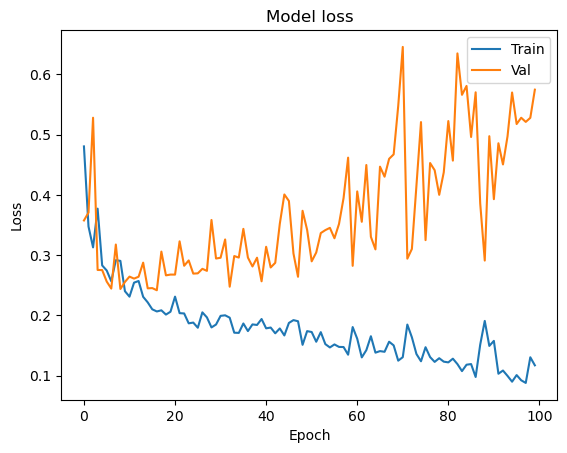

In [31]:
plt.plot(hist_2.history['loss'])
plt.plot(hist_2.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper right')
plt.show()

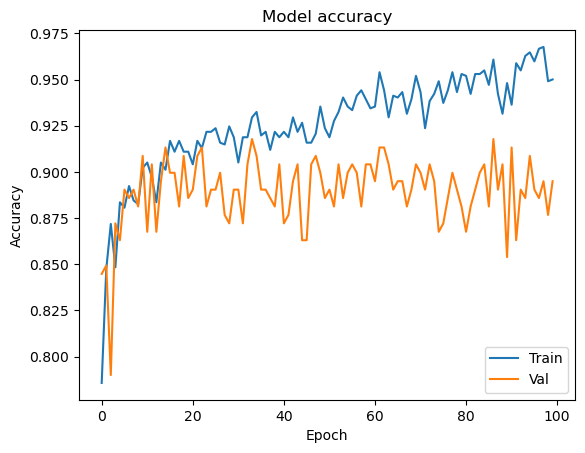

In [34]:
plt.plot(hist_2.history['accuracy'])
plt.plot(hist_2.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='lower right')
plt.show()


In [35]:
from keras.layers import Dropout
from keras import regularizers

In [37]:
model_3 = Sequential([
    Dense(1000, activation='relu', kernel_regularizer=regularizers.l2(0.01), input_shape=(10,)),
    Dropout(0.3),
    Dense(1000, activation='relu', kernel_regularizer=regularizers.l2(0.01)),
    Dropout(0.3),
    Dense(1000, activation='relu', kernel_regularizer=regularizers.l2(0.01)),
    Dropout(0.3),
    Dense(1000, activation='relu', kernel_regularizer=regularizers.l2(0.01)),
    Dropout(0.3),
    Dense(1, activation='sigmoid', kernel_regularizer=regularizers.l2(0.01)),
])

In [38]:
model_3.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

hist_3 = model_3.fit(X_train, Y_train,
          batch_size=32, epochs=100,
          validation_data=(X_val, Y_val))

Epoch 1/100
32/32 [==============================] - 3s 42ms/step - loss: 14.2197 - accuracy: 0.6018 - val_loss: 3.9009 - val_accuracy: 0.7854
Epoch 2/100
32/32 [==============================] - 1s 28ms/step - loss: 1.6904 - accuracy: 0.8082 - val_loss: 0.7001 - val_accuracy: 0.8128
Epoch 3/100
32/32 [==============================] - 1s 28ms/step - loss: 0.5664 - accuracy: 0.8591 - val_loss: 0.4935 - val_accuracy: 0.8813
Epoch 4/100
32/32 [==============================] - 1s 27ms/step - loss: 0.5182 - accuracy: 0.8659 - val_loss: 0.4734 - val_accuracy: 0.8950
Epoch 5/100
32/32 [==============================] - 1s 26ms/step - loss: 0.5054 - accuracy: 0.8659 - val_loss: 0.4802 - val_accuracy: 0.8630
Epoch 6/100
32/32 [==============================] - 1s 25ms/step - loss: 0.4900 - accuracy: 0.8787 - val_loss: 0.4473 - val_accuracy: 0.9041
Epoch 7/100
32/32 [==============================] - 1s 25ms/step - loss: 0.4841 - accuracy: 0.8748 - val_loss: 0.4497 - val_accuracy: 0.9041
Epoch

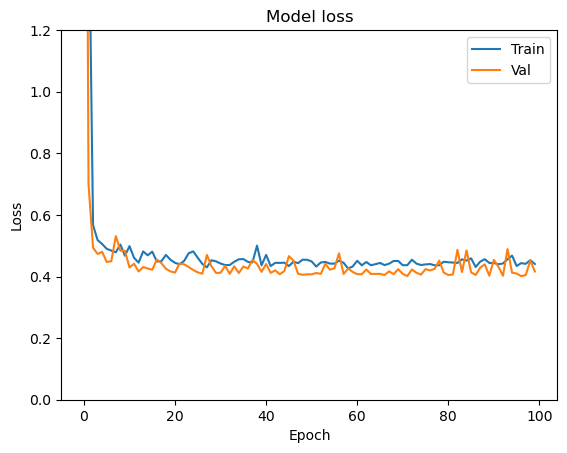

In [39]:
plt.plot(hist_3.history['loss'])
plt.plot(hist_3.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper right')
plt.ylim(top=1.2, bottom=0)
plt.show()

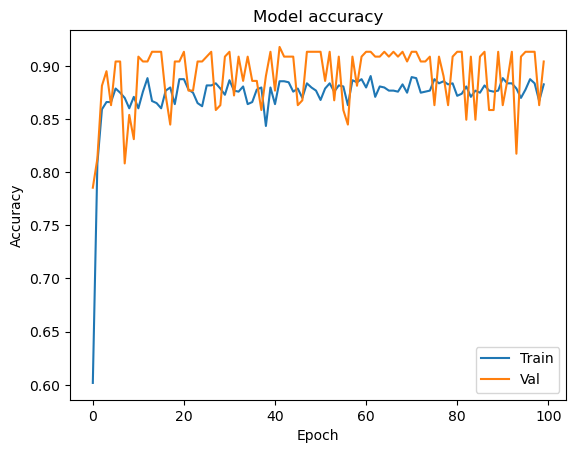

In [41]:
plt.plot(hist_3.history['accuracy'])
plt.plot(hist_3.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='lower right')
plt.show()
